# Análise de Dados - Loterias Caixa
<img src='http://loterias.caixa.gov.br/wps/wcm/connect/3dbf7d87-1ea2-4b63-9930-71641c746a6d/01_Mega_Sena_WPC.png?MOD=AJPERES&CACHEID=3dbf7d87-1ea2-4b63-9930-71641c746a6d' width=250>

---
### >>> Adição de bibliotecas, download, extração e leitura do arquivo de dados (Pandas DataFrame).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import io
import requests
from zipfile import ZipFile

arq = requests.get('http://www1.caixa.gov.br/loterias/_arquivos/loterias/D_megase.zip')   
ZipFile(io.BytesIO(arq.content)).extractall()
dflis = pd.read_html('d_mega.htm', thousands='.', decimal=',') # lista de DataFrames
df = dflis[0] # lista[0] contém o primeiro DataFrame
df

,Concurso,Data Sorteio,1ª Dezena,2ª Dezena,3ª Dezena,4ª Dezena,5ª Dezena,6ª Dezena,Arrecadacao_Total,Ganhadores_Sena,...,UF,Rateio_Sena,Ganhadores_Quina,Rateio_Quina,Ganhadores_Quadra,Rateio_Quadra,Acumulado,Valor_Acumulado,Estimativa_Prêmio,Acumulado_Mega_da_Virada
0,1,11/03/1996,41,5,4,52,30,33,0.0,0,...,&nbsp,0.00,17,39158.92,2016,330.21,SIM,1714650.23,0.0,0.00
1,2,18/03/1996,9,39,37,49,43,41,0.0,1,...,PR,2307162.23,65,14424.02,4488,208.91,NÃO,0.00,0.0,0.00
2,3,25/03/1996,36,30,10,11,29,47,0.0,2,...,RN,391192.51,62,10515.93,4261,153.01,NÃO,0.00,0.0,0.00
3,3,25/03/1996,36,30,10,11,29,47,0.0,2,...,SP,391192.51,62,10515.93,4261,153.01,NÃO,0.00,0.0,0.00
4,4,01/04/1996,6,59,42,27,1,5,0.0,0,...,&nbsp,0.00,39,15322.24,3311,180.48,SIM,717080.75,0.0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2581,2307,10/10/2020,38,53,46,55,33,16,32577475.5,0,...,&nbsp,0.00,45,41739.35,2828,948.81,SIM,3459972.23,6500000.0,70389092.21
2582,2308,14/10/2020,26,9,58,38,60,13,30017974.5,1,...,SP,6648106.25,57,30363.18,3408,725.47,NÃO,0.00,2500000.0,70844539.95
2583,2309,17/10/2020,33,60,11,29,9,30,30967605.0,0,...,&nbsp,0.00,38,46985.60,3092,824.91,SIM,24946942.36,29000000.0,71314395.95
2584,2310,20/10/2020,13,42,17,28,53,29,30927559.5,0,...,&nbsp,0.00,52,34291.23,3573,712.94,SIM,28231681.13,32000000.0,71783644.37


---
### >>> Remove as colunas 'Cidade' e 'UF' e as linhas repetidas.


In [2]:
dfsr = df.drop(columns=['Cidade', 'UF']) # remove as colunas que não se repetem
dfsr.drop_duplicates(inplace = True) # remove as linhas repetidas
dfsr.reset_index(drop = True, inplace = True) # reinicia os índices da tabela
dfsr

,Concurso,Data Sorteio,1ª Dezena,2ª Dezena,3ª Dezena,4ª Dezena,5ª Dezena,6ª Dezena,Arrecadacao_Total,Ganhadores_Sena,Rateio_Sena,Ganhadores_Quina,Rateio_Quina,Ganhadores_Quadra,Rateio_Quadra,Acumulado,Valor_Acumulado,Estimativa_Prêmio,Acumulado_Mega_da_Virada
0,1,11/03/1996,41,5,4,52,30,33,0.0,0,0.00,17,39158.92,2016,330.21,SIM,1714650.23,0.0,0.00
1,2,18/03/1996,9,39,37,49,43,41,0.0,1,2307162.23,65,14424.02,4488,208.91,NÃO,0.00,0.0,0.00
2,3,25/03/1996,36,30,10,11,29,47,0.0,2,391192.51,62,10515.93,4261,153.01,NÃO,0.00,0.0,0.00
3,4,01/04/1996,6,59,42,27,1,5,0.0,0,0.00,39,15322.24,3311,180.48,SIM,717080.75,0.0,0.00
4,5,08/04/1996,1,19,46,6,16,2,0.0,0,0.00,98,5318.10,5399,96.53,SIM,1342488.85,0.0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2306,2307,10/10/2020,38,53,46,55,33,16,32577475.5,0,0.00,45,41739.35,2828,948.81,SIM,3459972.23,6500000.0,70389092.21
2307,2308,14/10/2020,26,9,58,38,60,13,30017974.5,1,6648106.25,57,30363.18,3408,725.47,NÃO,0.00,2500000.0,70844539.95
2308,2309,17/10/2020,33,60,11,29,9,30,30967605.0,0,0.00,38,46985.60,3092,824.91,SIM,24946942.36,29000000.0,71314395.95
2309,2310,20/10/2020,13,42,17,28,53,29,30927559.5,0,0.00,52,34291.23,3573,712.94,SIM,28231681.13,32000000.0,71783644.37


---
### >>> Seleciona apenas as colunas dos números sorteados de cada concurso e calcula a qtde de vezes que cada número foi sorteado. Mostra também os números menos e mais sorteados.
+ #### Na primeira linha, dfsr.iloc[:, 2:8] também pode ser usado.



In [3]:
npdez = dfsr.loc[:, '1ª Dezena':'6ª Dezena'].to_numpy()
npqsor = np.array([[n, (npdez == n).sum()] for n in range(1, 61)]) # números e qtdes sorteadas (ou numpy.count_nonzero(df == x))

mi, ma = min(npqsor[:, 1]), max(npqsor[:, 1])
lmi = npqsor[:, 0][(npqsor[:, 1] == mi)] # seleciona os números que têm a mesma qtde de mi (qtde mínima).
lma = npqsor[:, 0][(npqsor[:, 1] == ma)] # o mesmo para a qtde máxima.
print(npqsor)
print(f'\nMínimo = {mi} {lmi}\nMáximo = {ma} {lma}')

[[  1 230]
 [  2 235]
 [  3 209]
 [  4 251]
 [  5 256]
 [  6 237]
 [  7 220]
 [  8 230]
 [  9 214]
 [ 10 263]
 [ 11 235]
 [ 12 228]
 [ 13 236]
 [ 14 219]
 [ 15 206]
 [ 16 239]
 [ 17 240]
 [ 18 234]
 [ 19 217]
 [ 20 222]
 [ 21 203]
 [ 22 202]
 [ 23 254]
 [ 24 245]
 [ 25 213]
 [ 26 191]
 [ 27 247]
 [ 28 244]
 [ 29 239]
 [ 30 243]
 [ 31 218]
 [ 32 235]
 [ 33 254]
 [ 34 242]
 [ 35 237]
 [ 36 239]
 [ 37 248]
 [ 38 235]
 [ 39 216]
 [ 40 223]
 [ 41 238]
 [ 42 249]
 [ 43 242]
 [ 44 239]
 [ 45 225]
 [ 46 228]
 [ 47 223]
 [ 48 209]
 [ 49 230]
 [ 50 232]
 [ 51 239]
 [ 52 235]
 [ 53 263]
 [ 54 246]
 [ 55 196]
 [ 56 237]
 [ 57 219]
 [ 58 228]
 [ 59 226]
 [ 60 213]]

Mínimo = 191 [26]
Máximo = 263 [10 53]


---
### >>> Gráfico de barras que mostra a qtde sorteada de cada número (ordem crescente). Destaque para os 15 mais sorteados.

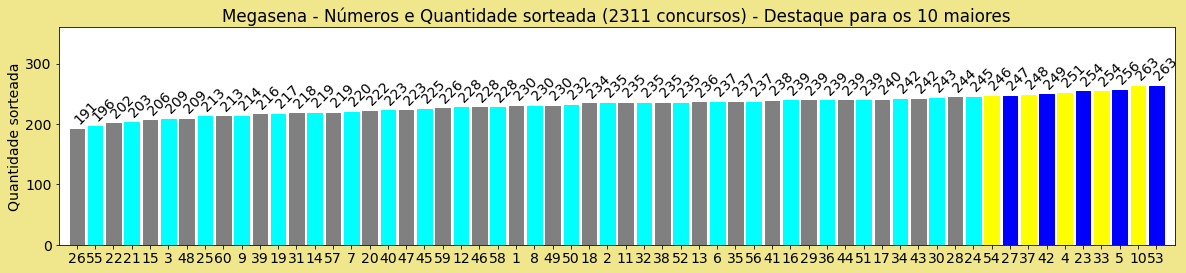

In [4]:
npqsord = np.array(sorted(npqsor, key=lambda x: x[1])) # ordena os números de acordo com a qtde de sorteios

plt.rcParams['figure.figsize'] = (20, 4) # tamanho da imagem
plt.rcParams['figure.facecolor'] = 'khaki'
plt.rcParams['font.size'] = 14 # tamanho da fonte dos textos
plt.axis([0, 61, 0, 360]) # intervalo dos eixos x e y

# gráfico de barras horiz. X e Y são listas
barras = plt.bar(range(1, 61), npqsord[:, 1], tick_label=npqsord[:, 0])

plt.title(f'Megasena - Números e Quantidade sorteada ({dfsr.shape[0]} concursos) - Destaque para os 10 maiores') # shape contém qtde de linhas e colunas (tuple)
plt.ylabel('Quantidade sorteada')
for i in range(60):
    cor1, cor2 = 'gray', 'cyan'
    if i >= 50: # cor diferente para os 15 valores com mais frequência nos sorteios
        cor1, cor2 = 'yellow', 'blue'
    barras[i].set_color(cor1 if i % 2 == 0 else cor2)
for i, bar in enumerate(barras):
    plt.text(bar.get_x() + bar.get_width() + 0.1, 1.02 * bar.get_height(), npqsord[i, 1],
             ha='center', va='bottom', rotation=45)
plt.show()

---
### Gráfico de 'torta' que mostra a qtde e a porcentagem de prêmios distribuídos por estado (UF).

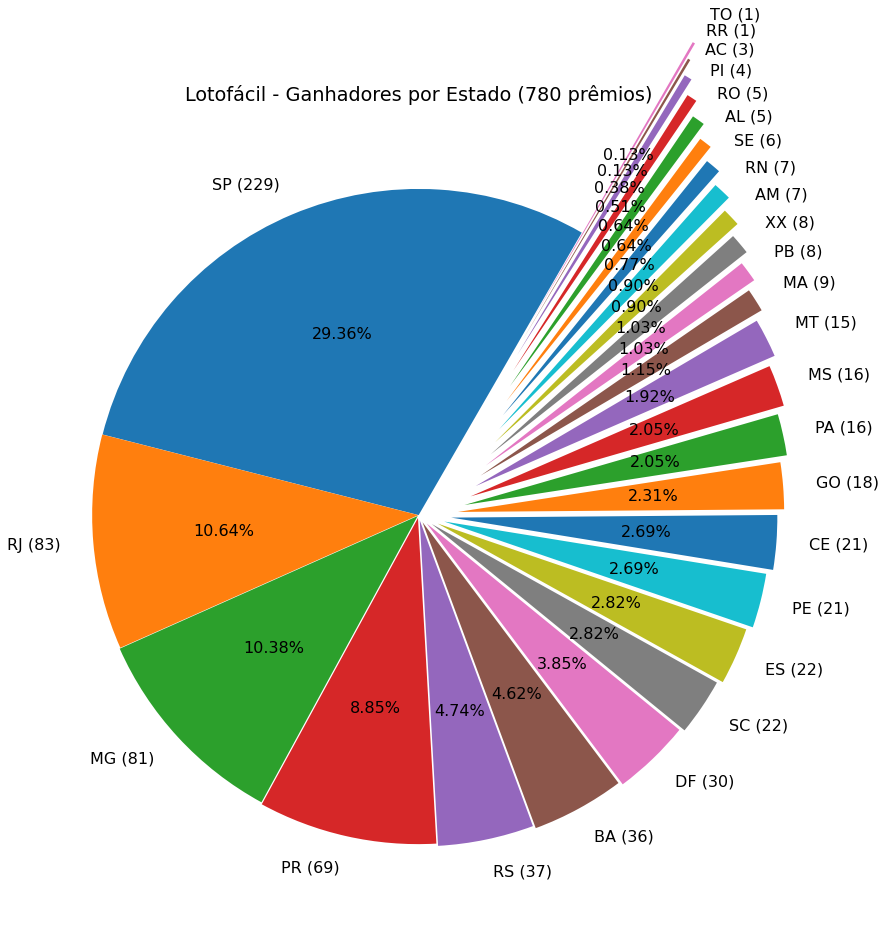

In [5]:
dfuf = df[df['UF'] != '&nbsp']
vcdfuf = dfuf['UF'].value_counts()
plt.rcParams['figure.figsize'] = (15, 15) # tamanho da imagem
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['font.size'] = 16 # tamanho da fonte dos textos
plt.pie(vcdfuf, [x ** 2 * 0.001 for x in range(len(vcdfuf))], 
        [vcdfuf.index[i] + ' (' + str(val) + ')' for i, val in enumerate(vcdfuf)], 
        autopct='%.2f%%', startangle=60)
plt.title(f'Lotofácil - Ganhadores por Estado ({sum(vcdfuf)} prêmios)') 
plt.show()